# 07 A Data-Driven Second Axis

**Can the two axes be found in the data instead of being assigned to it?**

Every measure in this project so far was built by deciding in advance what it should
capture. Valence was elicited from a language model asked for pleasantness. Arousal was
assembled from published word norms chosen because they are labelled *arousal*. The axes
exist because the project put them there.

Semo et al. take the opposite route. They learn emotion embeddings from tweets, run a
PCA over them, keep the first two components, rotate those with Varimax, and only then
look at the result and name the axes — one comes out looking like valence, the other
like arousal. Nothing is normalised, ranked, or fixed to a range. The structure is
whatever the emotion data happens to contain.

This notebook applies that procedure to the emotion probabilities already computed in
Notebook 03. It asks a single question: **left to itself, does this corpus produce a
valence axis and an arousal axis?**

---

### A note on what this notebook is for

**This is an exploratory notebook. It does not feed the pipeline.** Notebook 06 exports
the dashboard from the axes built in 02 to 05, and nothing here changes that. The result
is a cross-check on those axes from an independent direction, not a replacement for them.

It runs on the synthetic corpus. The final step explains carefully which of its findings
can survive that and which cannot.

In [1]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.decomposition import PCA

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

DATA = Path("../synthetic_dataset")

# ---- which dataset ----------------------------------------------------------
SOURCE = "synthetic"

if SOURCE == "synthetic":
    WORK = DATA / "synthetic"
elif SOURCE == "real":
    WORK = DATA / "results" / "real_run"
    WORK.mkdir(parents=True, exist_ok=True)
    print("!" * 70)
    print("SOURCE = 'real'. This run's outputs, and the outputs stored inside this")
    print("notebook's cells, contain real employee comments. Do not share the")
    print("executed copy.")
    print("!" * 70 + "\n")
else:
    raise ValueError("SOURCE must be 'synthetic' or 'real'")

EMOTION_FILE = WORK / f"{SOURCE}_emotions.parquet"
CIRCUMPLEX_FILE = WORK / f"{SOURCE}_circumplex.parquet"
OUTPUT = WORK / f"{SOURCE}_semo_axes.parquet"

# ---- the procedure ----------------------------------------------------------
DROP_NEUTRAL = True    # see step 2
STANDARDISE = True     # see step 2 — this departs from Semo et al., with reason
COMPONENTS = 2         # as in Semo et al.

# ---- drawing ----------------------------------------------------------------
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK_SOFT, INK_MUTED, BASELINE = "#0b0b0b", "#52514e", "#8a8880", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "legend.frameon": False,
})

emotions = pd.read_parquet(EMOTION_FILE)
circumplex = pd.read_parquet(CIRCUMPLEX_FILE)
print(f"{len(emotions):,} scored comments x {emotions.shape[1]} emotions")

2,500 scored comments x 28 emotions


---

## Step 1 — The matrix, and how it joins back

Notebook 03 stored the emotion probabilities without an identifier column. They are
aligned by the row index of the original survey table instead, which the parquet file
preserves. That is convenient but silent, and a silent join is the one thing that would
make everything downstream look plausible and be wrong.

So it is checked rather than assumed: the emotion index must reproduce exactly the rows
that carry a free-text comment.

One property of the matrix matters for what follows. The classifier is multi-label, so
each of the 28 probabilities is independent and the rows do not sum to one. The columns
are therefore not a composition, and an ordinary PCA over them is well defined.

In [2]:
# ============================================================
# The Matrix and the Join
# ============================================================

with_comment = circumplex[circumplex["has_comment"].astype(bool)]

assert emotions.index.equals(with_comment.index), "emotion rows do not match the corpus"
print(f"join verified: {len(emotions):,} emotion rows == {len(with_comment):,} "
      f"comments in {CIRCUMPLEX_FILE.name}")

reference = circumplex.loc[emotions.index,
                           ["valence", "arousal", "arousal_raw",
                            "criterion_arousal", "bert_adjusted"]]

row_sums = emotions.sum(axis=1)
print(f"\nrow sums: mean {row_sums.mean():.2f}, min {row_sums.min():.2f}, "
      f"max {row_sums.max():.2f}   (multi-label, so not 1.00)")

matrix = emotions.drop(columns=["neutral"]) if DROP_NEUTRAL else emotions.copy()
print(f"{matrix.shape[1]} emotions enter the PCA"
      f"{' (neutral dropped, see step 2)' if DROP_NEUTRAL else ''}")

join verified: 2,500 emotion rows == 2,500 comments in synthetic_circumplex.parquet

row sums: mean 1.42, min 0.18, max 4.00   (multi-label, so not 1.00)
27 emotions enter the PCA (neutral dropped, see step 2)


## Step 2 — Two departures from the original procedure, and why

Semo et al. do not scale their embeddings, and there is no reason they should: the
dimensions of a learned embedding are already on a common scale. Emotion probabilities
are not. The cell below shows how unevenly the variance is distributed across the 28
columns.

**`neutral` is dropped.** In this label set it is a residual category rather than an
emotion, and it moves opposite to everything else. Left in, it contributes a component
that separates comments carrying any emotion from comments carrying none — a real
distinction, but not one of the two the procedure is looking for. Step 8 reports what
keeping it would have changed.

**The columns are standardised.** This is the larger departure and it is not made
lightly. Run unscaled, the PCA is not a summary of the emotion structure; it is a
summary of the three highest-variance columns, and the axes it produces belong to those
columns almost alone. The cell below demonstrates this rather than asserting it.

In [3]:
# ============================================================
# Why the Columns Cannot Stay on Their Own Scale
# ============================================================

spread = emotions.var().sort_values(ascending=False)
print("variance per emotion, the six largest and the four smallest:")
for name, value in list(spread.items())[:6]:
    print(f"  {name:16s} {value:.5f}")
print("  ...")
for name, value in list(spread.items())[-4:]:
    print(f"  {name:16s} {value:.6f}")

print(f"\nthe largest column alone holds {spread.iloc[0] / spread.sum():.1%} "
      f"of the total variance")
print(f"the largest three hold {spread.iloc[:3].sum() / spread.sum():.1%}")
print("\nAn unscaled PCA optimises for exactly this quantity, so those three columns")
print("would decide both axes. The comparison in step 8 confirms it: run unscaled,")
print("the loadings of 22 of the 27 emotions are indistinguishable from zero.")

variance per emotion, the six largest and the four smallest:
  admiration       0.18615
  approval         0.13561
  disappointment   0.10309
  neutral          0.06722
  realization      0.05175
  confusion        0.03657
  ...
  relief           0.000799
  amusement        0.000783
  nervousness      0.000526
  grief            0.000002

the largest column alone holds 22.4% of the total variance
the largest three hold 51.2%

An unscaled PCA optimises for exactly this quantity, so those three columns
would decide both axes. The comparison in step 8 confirms it: run unscaled,
the loadings of 22 of the 27 emotions are indistinguishable from zero.


The imbalance is severe. `admiration` alone accounts for roughly a fifth of the total
variance and the three largest columns for about half of it, while the smallest columns
are four orders of magnitude below the largest.

Standardising costs something real: it treats a rare emotion as being as informative as
a common one, which is a claim about the data rather than a neutral operation. But the
alternative is worse, because it silently reduces a 27-dimensional structure to three
columns. Step 8 runs both so the choice can be inspected rather than trusted.

## Step 3 — The PCA, and how much structure there actually is

The procedure calls for the first two components. That instruction is worth examining
before it is followed, because it is only reasonable if the first two components are
distinct from the third. Six are computed here so the shape of the spectrum is visible.

In [4]:
# ============================================================
# Principal Components
# ============================================================

values = matrix.to_numpy(dtype=float)
values = values - values.mean(axis=0)
if STANDARDISE:
    values = values / values.std(axis=0)

survey = PCA(n_components=6, svd_solver="full").fit(values)
share = survey.explained_variance_ratio_

print(f"{'component':>10s} {'variance':>10s} {'cumulative':>12s}")
for k, part in enumerate(share):
    print(f"{'PC' + str(k + 1):>10s} {part:9.1%} {share[:k + 1].sum():11.1%}")

print(f"\nthe first {COMPONENTS} components carry {share[:COMPONENTS].sum():.1%} "
      f"of the variance")
print(f"the gap between PC{COMPONENTS} and PC{COMPONENTS + 1} is "
      f"{share[COMPONENTS - 1] - share[COMPONENTS]:.1%} of the total")

scores_full = values @ survey.components_.T
print("\nhow each unrotated component relates to the axes the project already has:")
print(f"{'':>6s}{'valence':>10s}{'arousal':>10s}{'criterion':>11s}{'bert_adj':>10s}")
for k in range(6):
    line = [spearmanr(scores_full[:, k], reference[column],
                      nan_policy="omit").statistic
            for column in ["valence", "arousal", "criterion_arousal", "bert_adjusted"]]
    print(f"{'PC' + str(k + 1):>6s}" + "".join(f"{value:>10.3f}" for value in line[:2])
          + f"{line[2]:>11.3f}{line[3]:>10.3f}")

 component   variance   cumulative
       PC1      9.0%        9.0%
       PC2      6.3%       15.3%
       PC3      5.7%       21.0%
       PC4      5.0%       26.0%
       PC5      4.9%       30.9%
       PC6      4.5%       35.4%

the first 2 components carry 15.3% of the variance
the gap between PC2 and PC3 is 0.6% of the total

how each unrotated component relates to the axes the project already has:
         valence   arousal  criterion  bert_adj
   PC1    -0.767     0.043     -0.076    -0.675
   PC2     0.414     0.124      0.060     0.368
   PC3     0.515     0.057      0.040     0.403
   PC4    -0.007    -0.010      0.011     0.007
   PC5     0.182    -0.109      0.017     0.166
   PC6     0.037    -0.051     -0.017    -0.002


**The spectrum is nearly flat.** The first component holds 9.0 % of the variance, the
second 6.3 %, and the third 5.7 %. Two components together account for 15.3 % — the
emotion matrix has no dominant two-dimensional structure for the procedure to find.

**The gap between the second and third component is 0.6 % of the total variance.** The
plane the rest of this notebook works in is therefore barely distinguishable from a
plane containing PC3, and the choice of *two* components is inherited from Semo et al.
rather than supported by this data. This matters for what follows: PC3 correlates
+0.515 with valence, so a meaningful part of the valence signal sits outside the plane
that is about to be rotated.

**Valence is already visible, and arousal is already absent.** PC1 reaches −0.767 with
the project's valence measure before any rotation. No component reaches beyond ±0.13
with arousal, and none beyond ±0.08 with the independent arousal criterion. That
observation is the theme of this notebook, and Step 6 turns it into something stronger
than an observation.

## Step 4 — The Varimax rotation

With exactly two components, Varimax has one degree of freedom: an angle. It cannot
change how much variance the plane holds, only how that variance is divided between the
two axes lying in it. It searches for *simple structure* — a solution in which each
emotion loads strongly on one axis and weakly on the other.

Rotation is applied to the loadings, meaning the components scaled by the square root of
their variance. Because the rotation matrix is orthogonal, the comment scores follow by
the same rotation, and the reconstruction is preserved exactly.

In [5]:
# ============================================================
# Varimax
# ============================================================

def varimax(loadings, tolerance=1e-9, iterations=200):
    """Kaiser's varimax. Returns the rotated loadings and the rotation matrix."""
    n_rows, n_cols = loadings.shape
    rotation, previous = np.eye(n_cols), 0.0
    for _ in range(iterations):
        rotated = loadings @ rotation
        left, singular, right = np.linalg.svd(
            loadings.T @ (rotated ** 3
                          - rotated @ np.diag((rotated ** 2).sum(axis=0)) / n_rows))
        rotation = left @ right
        if previous and singular.sum() / previous < 1 + tolerance:
            break
        previous = singular.sum()
    return loadings @ rotation, rotation


pca = PCA(n_components=COMPONENTS, svd_solver="full").fit(values)
raw_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings, rotation = varimax(raw_loadings)
scores = (values @ pca.components_.T) @ rotation

angle = np.degrees(np.arctan2(rotation[1, 0], rotation[0, 0]))
print(f"rotation angle: {angle:.1f} degrees")
print(f"variance in the plane, before {pca.explained_variance_ratio_.sum():.1%}, "
      f"after {pca.explained_variance_ratio_.sum():.1%}   (a rotation cannot change it)")

simplicity = lambda L: (L ** 4).sum() - ((L ** 2).sum(axis=0) ** 2).sum() / L.shape[0]
print(f"varimax criterion: {simplicity(raw_loadings):.4f} before, "
      f"{simplicity(loadings):.4f} after")

table = pd.DataFrame(loadings, index=matrix.columns,
                     columns=["rotated 1", "rotated 2"]).sort_values("rotated 1")
print("\nrotated loadings, the five extremes of each end:")
print(pd.concat([table.head(5), table.tail(5)]).round(3).to_string())

rotation angle: 24.9 degrees
variance in the plane, before 15.3%, after 15.3%   (a rotation cannot change it)
varimax criterion: 0.5966 before, 0.7824 after

rotated loadings, the five extremes of each end:
                rotated 1  rotated 2
approval           -0.483     -0.133
realization        -0.186     -0.431
optimism           -0.150     -0.222
confusion          -0.082     -0.279
admiration         -0.075      0.757
annoyance           0.428     -0.120
disappointment      0.511     -0.338
anger               0.516      0.034
sadness             0.578     -0.101
grief               0.694      0.095


Varimax settles on a rotation of about 25 degrees and improves the simplicity criterion,
so the procedure ran as intended. The question is what the two axes it produced actually
are.

**The first rotated axis is built from unpleasant emotions.** `grief` (+0.69),
`sadness` (+0.58), `anger` (+0.52) and `disappointment` (+0.51) sit at one end, with
`approval` (−0.48) at the other.

**The second is built from pleasant ones.** `admiration` (+0.76), `gratitude` (+0.49),
`joy` (+0.36) and `pride` (+0.33) at one end; `realization` (−0.43),
`disappointment` (−0.34) and `confusion` (−0.28) at the other.

Both axes are made of pleasantness. One is anchored in negative emotions and the other in
positive ones, which is the structure affect research calls Negative and Positive Affect
— not the valence and arousal pair the procedure was expected to yield. In a genuine
circumplex those two framings are the same thing seen at a 45-degree offset, so this
alone would not be fatal: rotating back should recover valence and arousal. Step 6 tries
exactly that.

## Step 5 — Naming the axes without consulting the answer

After rotation the axes have no order and no sign. Semo et al. resolve this by looking at
the result and interpreting it. Done informally that is the weakest point of the whole
procedure, so it is made explicit here.

The temptation is to name the axes by correlating them with the project's existing
valence and arousal measures. That would be circular, because those same measures are the
comparison in Step 8. The naming is done from the **loadings** alone instead, against two
per-emotion reference scales that never touch a single comment:

- `ACTIVATION` is taken unchanged from Notebook 03, where it was written down before any
  of this was computed.
- `PLEASANTNESS` is its counterpart, assigned here on the same reasoning.

Each rotated axis is compared with both scales. The axis matching pleasantness more
closely becomes valence, the other becomes arousal, and each is signed so that its
reference correlation is positive. Two bits of information, decided by theory rather than
by the answer.

In [6]:
# ============================================================
# Anchors
# ============================================================

# unchanged from notebook 03
ACTIVATION = {
    "anger": 1.0, "annoyance": 0.8, "disapproval": 0.6, "disgust": 0.8, "fear": 0.9,
    "nervousness": 0.9, "excitement": 1.0, "joy": 0.8, "surprise": 0.9,
    "amusement": 0.7, "desire": 0.7, "optimism": 0.6, "pride": 0.7, "admiration": 0.5,
    "love": 0.6, "gratitude": 0.4, "approval": 0.3, "caring": 0.4, "curiosity": 0.5,
    "realization": 0.3, "relief": 0.2, "confusion": 0.5, "embarrassment": 0.5,
    "disappointment": 0.3, "remorse": 0.3, "sadness": 0.2, "grief": 0.3, "neutral": 0.0,
}

# its counterpart on the same 0..1 reasoning
PLEASANTNESS = {
    "joy": 1.0, "love": 0.95, "excitement": 0.9, "gratitude": 0.9, "admiration": 0.85,
    "pride": 0.85, "amusement": 0.85, "optimism": 0.8, "relief": 0.8, "caring": 0.75,
    "approval": 0.7, "desire": 0.65, "curiosity": 0.6, "surprise": 0.55,
    "realization": 0.5, "neutral": 0.5, "confusion": 0.35, "nervousness": 0.25,
    "embarrassment": 0.25, "disapproval": 0.25, "annoyance": 0.2, "fear": 0.15,
    "disappointment": 0.15, "remorse": 0.15, "sadness": 0.1, "anger": 0.1,
    "disgust": 0.1, "grief": 0.05,
}

pleasant = np.array([PLEASANTNESS[name] for name in matrix.columns])
activating = np.array([ACTIVATION[name] for name in matrix.columns])

fit = np.array([[np.corrcoef(loadings[:, k], scale)[0, 1]
                 for scale in (pleasant, activating)]
                for k in range(COMPONENTS)])

print(f"{'':>12s}{'~ pleasantness':>16s}{'~ activation':>14s}")
for k in range(COMPONENTS):
    print(f"{'rotated ' + str(k + 1):>12s}{fit[k, 0]:>16.3f}{fit[k, 1]:>14.3f}")

valence_axis = int(np.argmax(np.abs(fit[:, 0])))
arousal_axis = 1 - valence_axis
valence_sign = np.sign(fit[valence_axis, 0])
arousal_sign = np.sign(fit[arousal_axis, 1])

print(f"\nrotated {valence_axis + 1} becomes valence "
      f"(sign {valence_sign:+.0f}), rotated {arousal_axis + 1} becomes arousal "
      f"(sign {arousal_sign:+.0f})")

semo = pd.DataFrame({"semo_valence": scores[:, valence_axis] * valence_sign,
                     "semo_arousal": scores[:, arousal_axis] * arousal_sign},
                    index=matrix.index)
emotion_map = pd.DataFrame({"valence": loadings[:, valence_axis] * valence_sign,
                            "arousal": loadings[:, arousal_axis] * arousal_sign},
                           index=matrix.columns)

print(f"\nthe two axes are orthogonal by construction: "
      f"spearman {spearmanr(semo['semo_valence'], semo['semo_arousal']).statistic:+.3f}")
print("scores are left in PCA units — not rescaled, not ranked, as in the original.")

              ~ pleasantness  ~ activation
   rotated 1          -0.727        -0.011
   rotated 2           0.557         0.147

rotated 1 becomes valence (sign -1), rotated 2 becomes arousal (sign +1)

the two axes are orthogonal by construction: spearman +0.022
scores are left in PCA units — not rescaled, not ranked, as in the original.


The pleasantness scale picks its axis at −0.73, against +0.56 for the other — a clear
margin, though the fact that it matches the second axis at +0.56 at all is already a
warning. The activation scale picks nothing: its best match is +0.15, close enough to
zero that the second axis is being named arousal purely because it is the one left over.

That is already the answer in miniature. The next step establishes that it is not an
artefact of this particular rotation.

## Step 6 — Is arousal in the plane at all?

The result so far could have two quite different explanations. Either Varimax chose a
poor angle and a better one would separate valence from arousal, or the plane spanned by
the first two components does not contain an arousal direction for any angle to find.

These are distinguishable. Rotating within a plane only moves the axes around inside it,
so sweeping the angle across a half-turn passes through every axis the plane can produce.
If some rotation yields arousal, the sweep finds it. If none does, the missing dimension
is a property of the plane and no rotation can repair it.

The sweep below is the decisive test in this notebook, and it does not depend on the
choice of Varimax at all.

the best any axis in this plane can do, over all rotations:
  the valence measure      0.799  at 166 degrees
  the arousal measure      0.161  at 51 degrees
  the arousal criterion    0.088  at 127 degrees


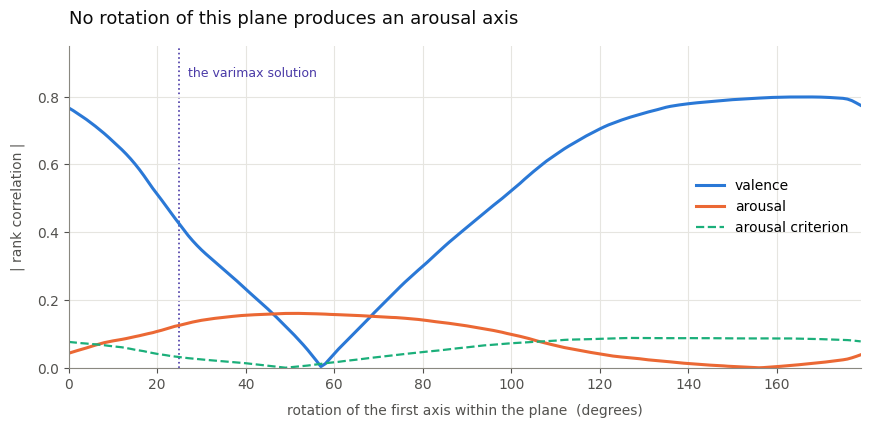

In [7]:
# ============================================================
# Every Rotation the Plane Allows
# ============================================================

plane = values @ pca.components_.T
degrees = np.arange(0, 180, 1.0)

def turn(deg):
    r = np.radians(deg)
    return plane @ np.array([[np.cos(r), -np.sin(r)], [np.sin(r), np.cos(r)]])

sweep = pd.DataFrame(
    [{"degrees": deg,
      "valence": abs(spearmanr(turn(deg)[:, 0], reference["valence"],
                               nan_policy="omit").statistic),
      "arousal": abs(spearmanr(turn(deg)[:, 0], reference["arousal"],
                               nan_policy="omit").statistic),
      "criterion": abs(spearmanr(turn(deg)[:, 0], reference["criterion_arousal"],
                                 nan_policy="omit").statistic)}
     for deg in degrees])

print("the best any axis in this plane can do, over all rotations:")
for column, label in [("valence", "the valence measure"),
                      ("arousal", "the arousal measure"),
                      ("criterion", "the arousal criterion")]:
    best = sweep.loc[sweep[column].idxmax()]
    print(f"  {label:24s} {best[column]:.3f}  at {best['degrees']:.0f} degrees")

fig, ax = plt.subplots(figsize=(9.0, 4.6))
fig.subplots_adjust(left=0.09, right=0.97, top=0.86, bottom=0.16)

ax.plot(sweep["degrees"], sweep["valence"], color=BLUE, lw=2.2, label="valence")
ax.plot(sweep["degrees"], sweep["arousal"], color=ORANGE, lw=2.2, label="arousal")
ax.plot(sweep["degrees"], sweep["criterion"], color=AQUA, lw=1.6, ls="--",
        label="arousal criterion")
ax.axvline(angle % 180, color=VIOLET, lw=1.2, ls=":", zorder=1)
ax.text(angle % 180 + 2, 0.86, "the varimax solution", color=VIOLET, fontsize=9)

ax.set_xlim(0, 179)
ax.set_ylim(0, 0.95)
ax.set_xlabel("rotation of the first axis within the plane  (degrees)", labelpad=9)
ax.set_ylabel("| rank correlation |", labelpad=9)
ax.set_title("No rotation of this plane produces an arousal axis",
             loc="left", pad=16, fontsize=13)
ax.legend(loc="center right")
plt.savefig(WORK / f"{SOURCE}_semo_rotation_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

**Valence rises to 0.80 and arousal never leaves the floor.** At 166 degrees an axis in
this plane tracks the project's valence measure at 0.799 — a strong agreement, reached by
a route that shares no component with how valence was originally measured. The emotion
classifier and the language model are describing the same thing.

**Arousal reaches 0.161 at its highest, and the independent criterion 0.088.** The orange
curve is flat because there is nothing for the rotation to find. This is not a failure of
Varimax; Varimax lands where the dotted line is, and every other angle is no better. The
plane spanned by the first two components of the emotion matrix contains a valence
direction and, to a first approximation, nothing else.

**The arousal curve peaks where the valence curve collapses, which gives it away.** Its
maximum is at 51 degrees and the valence curve reaches its minimum at 57 — the two nearly
coincide. Whatever the second axis is picking up is not an independent dimension but the
remainder left over once valence is rotated out of the way, and at 0.161 that remainder is
the height of the noise. Had the plane held both dimensions, the figure would show two
tall peaks about 90 degrees apart. It shows one peak and a flat line.

This is the same conclusion Notebook 03 reached from the opposite direction. There, a
hand-made mapping from emotions to activation was tested, found to track pleasantness far
more strongly than activation, and rejected in favour of word norms. The natural reading
at the time was that the hand-made mapping was at fault. The sweep above suggests
otherwise: no mapping from these emotion probabilities to an activation score could have
worked, because the activation information is not in them to begin with. Rejecting that
candidate was the right call for a reason better than the one given.

## Step 7 — The map the procedure produces

Whatever the axes turn out to mean, the loadings place all 27 emotions in one plane, and
that map is worth looking at directly. Each emotion sits where the rotated components put
it; the colouring is the `PLEASANTNESS` anchor, so agreement between the layout and the
colours is visible without reading the labels.

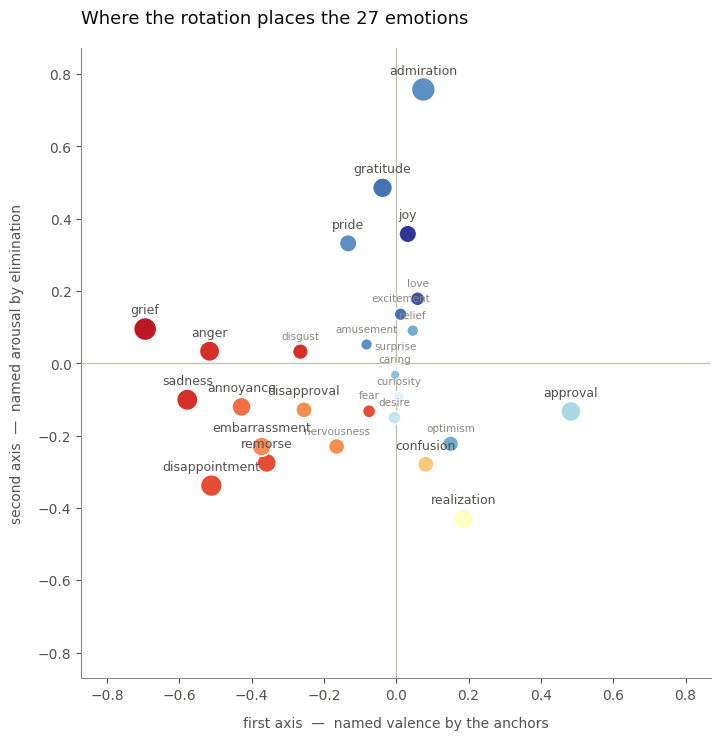

colour is the PLEASANTNESS anchor, size is distance from the origin


In [8]:
# ============================================================
# The Emotion Map
# ============================================================

fig, ax = plt.subplots(figsize=(9.2, 8.4))
fig.subplots_adjust(left=0.10, right=0.96, top=0.87, bottom=0.12)

ax.axhline(0, color=BASELINE, lw=1, zorder=1)
ax.axvline(0, color=BASELINE, lw=1, zorder=1)

warmth = plt.cm.RdYlBu([PLEASANTNESS[name] for name in emotion_map.index])
strength = np.hypot(emotion_map["valence"], emotion_map["arousal"])
ax.scatter(emotion_map["valence"], emotion_map["arousal"],
           s=40 + 260 * strength / strength.max(),
           c=warmth, edgecolors="white", linewidths=1.2, zorder=3)

for name, point in emotion_map.iterrows():
    prominent = strength[name] > strength.quantile(0.45)
    ax.annotate(name, (point["valence"], point["arousal"]),
                textcoords="offset points", xytext=(0, 11 if prominent else 9),
                ha="center", fontsize=9 if prominent else 7.5,
                color=INK_SOFT if prominent else INK_MUTED, zorder=4)

limit = 1.15 * max(abs(emotion_map.to_numpy()).max(), 0.1)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)
ax.set_aspect("equal")
ax.grid(False)
ax.set_xlabel("first axis  —  named valence by the anchors", labelpad=10)
ax.set_ylabel("second axis  —  named arousal by elimination", labelpad=10)
ax.set_title("Where the rotation places the 27 emotions",
             loc="left", pad=18, fontsize=13)
plt.savefig(WORK / f"{SOURCE}_semo_emotion_map.png", dpi=200, bbox_inches="tight")
plt.show()

print("colour is the PLEASANTNESS anchor, size is distance from the origin")

The horizontal spread follows the colouring — unpleasant emotions to one side, pleasant
ones to the other, at a correlation of +0.73 across the 27 loadings, with the anchor scale
never having been shown to the PCA. That is the valence axis being recovered from the
data. The alignment is a tendency rather than a rank order: `approval` reaches furthest
into the pleasant half while `joy` and `admiration` sit close to the origin.

The vertical spread does not follow anything comparable. `admiration` and `gratitude` sit
high, `realization` and `disappointment` low — a separation between expressed appreciation
and sober statement, which is a distinction the corpus evidently contains but not an
activation one. Calm `gratitude` and energetic `excitement` should be far apart on an
arousal axis. They are not.

Most emotions cluster near the origin, which is the flat spectrum from Step 3 seen from
another side: a handful of emotions carry the structure and the rest contribute little.

## Step 8 — What the four variants would have given

Two decisions were made in Step 2 against the letter of the original procedure. Both are
now run in all combinations, so their effect can be read off rather than argued about.

The columns to watch are the last two. `valence agreement` is the sanity check — the
procedure should recover the axis the project already measures well. `arousal agreement`
is the question the notebook was written to answer.

In [9]:
# ============================================================
# The Decisions, Taken and Untaken
# ============================================================

def procedure(drop_neutral, standardise):
    """The whole notebook in one function, returning the numbers that distinguish it."""
    frame = emotions.drop(columns=["neutral"]) if drop_neutral else emotions
    block = frame.to_numpy(dtype=float)
    block = block - block.mean(axis=0)
    if standardise:
        block = block / block.std(axis=0)

    model = PCA(n_components=COMPONENTS, svd_solver="full").fit(block)
    rotated, turn_by = varimax(model.components_.T * np.sqrt(model.explained_variance_))
    points = (block @ model.components_.T) @ turn_by

    anchor = np.array([[np.corrcoef(rotated[:, k], np.array([scale[name]
                                                             for name in frame.columns]))[0, 1]
                        for scale in (PLEASANTNESS, ACTIVATION)] for k in range(COMPONENTS)])
    first = int(np.argmax(np.abs(anchor[:, 0])))
    v = points[:, first] * np.sign(anchor[first, 0])
    a = points[:, 1 - first] * np.sign(anchor[1 - first, 1])

    loud = (np.abs(rotated).max(axis=1) < 0.05).sum()
    return {
        "neutral": "dropped" if drop_neutral else "kept",
        "scaling": "standardised" if standardise else "centred only",
        "variance": model.explained_variance_ratio_.sum(),
        "near-zero loadings": f"{loud} of {frame.shape[1]}",
        "valence agreement": spearmanr(v, reference["valence"],
                                       nan_policy="omit").statistic,
        "arousal agreement": spearmanr(a, reference["arousal"],
                                       nan_policy="omit").statistic,
        "arousal axis ~ valence": spearmanr(a, reference["valence"],
                                            nan_policy="omit").statistic,
    }


variants = pd.DataFrame([procedure(drop_neutral, standardise)
                         for drop_neutral in (True, False)
                         for standardise in (True, False)])
print(variants.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print("\nAn internal check: 'arousal' in the circumplex file is the rank transform of")
print("'arousal_raw', so a rank correlation must be identical against either. "
      f"{spearmanr(semo['semo_arousal'], reference['arousal'], nan_policy='omit').statistic:+.3f}"
      f" and "
      f"{spearmanr(semo['semo_arousal'], reference['arousal_raw'], nan_policy='omit').statistic:+.3f}")

neutral      scaling  variance near-zero loadings  valence agreement  arousal agreement  arousal axis ~ valence
dropped standardised     0.153            2 of 27              0.426              0.053                   0.668
dropped centred only     0.489           22 of 27              0.658              0.156                  -0.390
   kept standardised     0.150            2 of 28              0.423              0.076                   0.640
   kept centred only     0.454           22 of 28              0.643              0.162                  -0.400

An internal check: 'arousal' in the circumplex file is the rank transform of
'arousal_raw', so a rank correlation must be identical against either. +0.053 and +0.053


**No variant produces arousal.** The best agreement anywhere in the grid is 0.16, and the
column beside it is the reason: in every variant the axis named arousal correlates more
strongly with *valence* than with arousal. Under the centred-only variants it does so
negatively, under the standardised ones positively, which is a sign flip rather than a
difference in kind. The second axis is a valence axis throughout.

**The centred-only variants look better on valence and are worse.** They reach 0.66
against 0.43, but the neighbouring column shows why that number should not be trusted:
running unscaled, 22 of the 27 emotions end up with loadings below 0.05 on both axes. The
axes are three columns wearing the name of a 27-dimensional structure, and one of those
columns, `admiration`, happens to be a good valence marker in this corpus. A high
correlation obtained that way is not the procedure succeeding.

**Dropping `neutral` changes almost nothing** — a few hundredths on either measure. It
was the right call for tidiness rather than for consequence, and the notebook would
report the same findings with it kept.

**One number is worth pausing on.** The axis the anchors named valence agrees with the
project's valence at 0.43, while the axis they named arousal agrees with it at 0.67. The
anchors and the measurement disagree about which rotated axis is the valence one. Both
are, which is exactly why the question has no stable answer, and it is the sharpest
symptom of a plane holding one dimension where the procedure assumes two. Step 6 already
showed that a rotation to 166 degrees does better than either at 0.80.

## Step 9 — What the synthetic corpus can and cannot establish

The comments here were assembled by a generator from opener, body and closer fragments,
selected by a drawn emotion label and a valence level. That generator is not part of this
repository. What matters for the findings above is this: emotional content is an *input*
to it, not a property of observed feedback.

**The valence result is weakened by it.** An emotion classifier recovering valence from
text whose valence was chosen before the text existed is a shorter inference than it
looks. The agreement of 0.80 demonstrates that the machinery works end to end — the join,
the PCA, the rotation, the anchoring — but it is not evidence about real feedback.

**The arousal result is weakened less, and not in a way that rescues it.** Activation was
never a parameter of the generator, so its absence from the emotion matrix may reflect
the generator rather than employee comments. That much is a genuine limitation. But the
finding does not stand alone: Notebook 03 reached the same conclusion using published
word norms and an independent arousal criterion derived from survey items. Two routes
that share no method agree that these emotion probabilities do not carry activation.

**What would settle it.** Running this notebook on a corpus whose emotional content was
not chosen in advance is the direct test, and it needs no change to the code — only
emotion probabilities in the same shape. The sweep in Step 6 is the plot to look at.
Should the orange curve rise there, the absence found here was the generator's; should it
stay flat, it is the classifier's.

**A second option, if the picture stays unclear.** The generating emotion label was not
carried into the output, so no ground truth exists against which any of this can be
scored directly. Regenerating the synthetic corpus with that label retained would supply
one. That is a change to Notebook 01 and is left as a note rather than made here.

In [10]:
# ============================================================
# Export
# ============================================================

semo.to_parquet(OUTPUT)
emotion_map.to_csv(WORK / f"{SOURCE}_semo_loadings.csv", sep=";",
                   encoding="utf-8-sig", decimal=",")
variants.to_csv(WORK / f"{SOURCE}_semo_variants.csv", index=False, sep=";",
                encoding="utf-8-sig", decimal=",")

print(f"written: {OUTPUT.name}, {SOURCE}_semo_loadings.csv, "
      f"{SOURCE}_semo_variants.csv,")
print(f"         {SOURCE}_semo_emotion_map.png, {SOURCE}_semo_rotation_sweep.png")
print(f"\n{len(semo):,} comments scored on both axes, joinable on the index of "
      f"{CIRCUMPLEX_FILE.name}")
print("\nNothing here feeds notebook 06. The pipeline keeps the axes from 02 to 05.")

written: synthetic_semo_axes.parquet, synthetic_semo_loadings.csv, synthetic_semo_variants.csv,
         synthetic_semo_emotion_map.png, synthetic_semo_rotation_sweep.png

2,500 comments scored on both axes, joinable on the index of synthetic_circumplex.parquet

Nothing here feeds notebook 06. The pipeline keeps the axes from 02 to 05.


## Key Findings

**The procedure recovers valence from the emotion data, and recovers it well.** Some axis
in the plane of the first two components agrees with the project's valence measure at
0.80 without ever being told what valence is. Valence is a real, dominant structure in
these comments, findable by a method that has nothing in common with how Notebook 02
measured it.

**It does not recover arousal, and the reason is not the rotation.** Sweeping every angle
the plane permits, the best agreement with arousal is 0.161 and with the independent
arousal criterion 0.088. Varimax is not at fault and no alternative rotation would help.
The dimension is absent from the plane rather than misplaced within it.

**Both rotated axes are made of pleasantness.** One is anchored in negative emotions and
one in positive, resembling the Negative and Positive Affect pair rather than valence and
arousal. In a true circumplex those framings are equivalent up to a rotation, so the
distinction would not matter — here it does, because rotating back recovers no second
dimension.

**This confirms Notebook 03's decision by an independent route, and improves its
reasoning.** Emotion-based arousal was rejected there because it tracked pleasantness
rather than activation, which suggested the hand-made mapping was to blame. No mapping
could have succeeded: the activation information is not present in the emotion
probabilities at all.

**The original procedure's refusal to scale does not transfer to this data.** Learned
embedding dimensions share a scale; 28 emotion probabilities do not, with one column
holding a fifth of the total variance. Run unscaled, 22 of 27 emotions receive
effectively zero loading and the axes belong to three columns. The higher valence
correlation this produces (0.66) is an accident of one well-behaved column rather than a
better result.

**Two components are Semo's choice, not this data's.** The spectrum is flat — 9.0 %,
6.3 %, 5.7 % — and the third component holds a further +0.515 of valence signal outside
the rotated plane. On this corpus the procedure is being asked to find two dimensions
where the data offers no clear two-dimensional structure.

**These findings are provisional until the notebook is run on text that was not
generated.** The synthetic comments were produced from a valence level, which makes the
valence result partly circular — the classifier recovers something that was decided before
the text existed. The arousal finding is more robust, since activation was never a
generator parameter and Notebook 03 reaches the same conclusion by an independent route.
But only a corpus with unchosen emotional content can settle either of them.

---

*This notebook is exploratory and does not feed the pipeline. Notebook 06 continues to
export the dashboard from the axes built in Notebooks 02 to 05.*